In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Part A

Least Squares
Slope: 0.9996245690830545, Intercept: 0.5387500600703249
Mean Squared Error: 0.1110
R-squared: 0.9431

Poly Fit
Polynomial Coefficients:  [-0.11533258  1.02560992 -1.57398165  2.25300958]
Mean Squared Error: 0.0000
R-squared: 1.0000


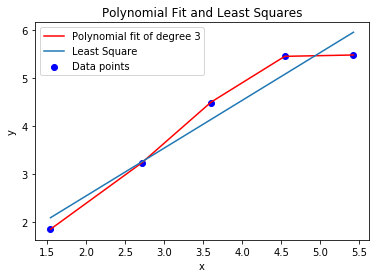

In [41]:
np.random.seed(0)

# Data Points
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

X2 = np.sort(X + np.random.rand(len(X)))
Y2 = Y + np.random.rand(len(Y))

# Stack the design matrix with a column of ones (for the intercept)
A2 = np.vstack([X2, np.ones(len(X2))]).T

# Solve using least squares
m2, c2 = np.linalg.lstsq(A2, Y2, rcond=None)[0]

# Polynomial fitting using NumPy's polyfit
degree = 3
coefficients = np.polyfit(X2, Y2, degree)

# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

y2 = m2 * X2 + c2

# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(X2)

# Least Squared
print("Least Squares")
print(f"Slope: {m2}, Intercept: {c2}")

# Mean Squared Error (MSE) for Least Squared
mse = np.mean((Y2 - y2)**2)
print(f'Mean Squared Error: {mse:.4f}')

# R-squared value for Least Squared
ss_total = np.sum((Y2 - np.mean(Y2))**2)
ss_res = np.sum((Y2 - y2)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

# Polyfit
print("\nPoly Fit")
print("Polynomial Coefficients: ", coefficients)

# Mean Squared Error (MSE)
mse = np.mean((Y2 - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')

# R-squared value
ss_total = np.sum((Y2 - np.mean(Y2))**2)
ss_res = np.sum((Y2 - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

# Step 4: Plotting the results
plt.scatter(X2, Y2, color='blue', label='Data points') # Original data points
plt.plot(X2, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.plot(X2, y2, label=f'Least Square')
plt.title('Polynomial Fit and Least Squares')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


# Part B


Poly UnderFit
Polynomial Coefficients:  [0.99962457 0.53875006]
Mean Squared Error: 0.1110
R-squared: 0.9431

Poly Overfit
Mean Squared Error: 0.0000
R-squared: 1.0000


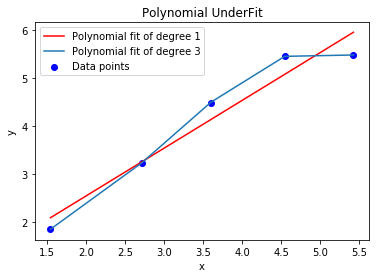

In [43]:

np.random.seed(0)

# Polynomial fitting using NumPy's polyfit
degree2 = 1
coefficients2 = np.polyfit(X2, Y2, degree2)

# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial2 = np.poly1d(coefficients2)

# Generate predicted y-values based on the fitted polynomial
y_pred2 = polynomial2(X2)


# Polyfit
print("\nPoly UnderFit")
print("Polynomial Coefficients: ", coefficients2)

# Mean Squared Error (MSE)
mse2 = np.mean((Y2 - y_pred2)**2)
print(f'Mean Squared Error: {mse2:.4f}')

# R-squared value
ss_total2 = np.sum((Y2 - np.mean(Y2))**2)
ss_res2 = np.sum((Y2 - y_pred2)**2)
r_squared2 = 1 - (ss_res2 / ss_total2)
print(f'R-squared: {r_squared2:.4f}')

print("\nPoly Overfit")
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')

# Step 4: Plotting the results
plt.scatter(X2, Y2, color='blue', label='Data points') # Original data points
plt.plot(X2, y_pred2, color='red', label=f'Polynomial fit of degree {degree2}')
plt.plot(X2, y_pred, label=f'Polynomial fit of degree {degree}')
plt.title('Polynomial UnderFit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


# Part C

In [46]:
# Create Vandermonde matrix for a polynomial of degree
degree3 = 2
V = np.vander(X, N=degree3+1, increasing=True)

# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, Y)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)